# 06 · Taxonomy mapping & structural validation

Three structural validations of the two-layer (direction × control-operation) taxonomy, each ending in a **"What we conclude"** cell:
1. **the 65-signal mapping** — every coupling signal placed on both axes;
2. **the signal-pairing / contrast analysis** (full reproduction of `docs/criteria/signal-pairing.md`) — polarity poles, direction & completeness contrasts, the benchmark/structural/set-aside verdicts, and the curated masking & position layers;
3. **Clark grounding-acts vs STPA control-ops**, head-to-head on chat signals and on real agentic tool calls.

**Backs:** `docs/criteria/signal-pairing.md`, `docs/comparison.md`, `docs/methodology/advisor-update.md`.
**Scripts:** `build_control_mapping.compute()`, `pair_analysis.compute()`, `taxonomy_compare.compute()`.

In [1]:
import sys, pathlib, json
ROOT = pathlib.Path.cwd(); ROOT = ROOT if (ROOT/"src").exists() else ROOT.parent
sys.path.insert(0, str(ROOT/"src"))
import pandas as pd
pd.set_option("display.max_rows", 120)
print("repo root:", ROOT)

repo root: /data/wang/junh/githubs/human-agent-coupling-errors


# 1 · The 65-signal mapping
Doc claim: coupling **42**, support_feature **10**, trigger 5, direct_coupling 3, outcome 4, mechanism_both 1; L1 populated **45**. Coupling by op: report_state 15, recover_repair 11, act_execute 6, ask_clarify 4, maintain_state 4, confirm_authorize 1, stop_defer 1, **seek_inspect 0**.

In [2]:
import build_control_mapping as bcm
m = bcm.compute()
print("relation_type:", m["relation_type"])
print("L1 populated:", m["l1"], "total", sum(m["l1"].values()))
pd.Series(m["coupling_by_op"]).rename("n_signals").to_frame().sort_values("n_signals", ascending=False)

relation_type: {'coupling': 42, 'direct_coupling_when_material': 1, 'direct_coupling': 1, 'outcome_from_direct_coupling': 1, 'trigger_H2AI': 5, 'support_feature_AI2H': 6, 'rapport_support_AI2H': 3, 'support_feature_bridge': 1, 'outcome': 4, 'mechanism_both': 1}
L1 populated: {'H2AI': 23, 'AI2H': 22} total 45


,n_signals
report_state,15
recover_repair,11
act_execute,6
ask_clarify,4
maintain_state,4
confirm_authorize,1
stop_defer,1


In [3]:
pd.DataFrame(m["rows"], columns=m["columns"])  # the full mapping

,signal,l1,control_op,polarity,relation_type
0,silent_assumption,H2AI,report_state,failure,coupling
1,ai_stated_interpretation,H2AI,report_state,positive,coupling
2,false_confidence,AI2H,report_state,failure,coupling
3,performative_hedge,AI2H,report_state,failure,coupling
4,problem_ignored,AI2H,report_state,failure,coupling
5,problem_surfaced,AI2H,report_state,positive,coupling
6,appropriate_confidence,AI2H,report_state,positive,coupling
7,appropriate_hedge,AI2H,report_state,positive,coupling
8,ai_hedges_uncertainty,AI2H,report_state,positive,coupling
9,ai_asserts_knowledge_limit,AI2H,report_state,positive,coupling


### What we conclude — the mapping is well-formed and bidirectional

- Every one of the **42 `coupling`** signals lands in exactly one `(control_op, direction)` cell — the taxonomy partitions the coupling vocabulary cleanly (the other 23 signals are triggers / support-features / outcomes, i.e. *not* coupling and correctly left uncategorized on the two axes).
- **45 of 65** signals carry a Layer-1 direction, split **23 H→AI / 22 AI→H** — almost exactly even. Both directions of the gulf are populated by real wild-data signals, so the H→AI (uptake) vs AI→H (legibility) split is not an artifact of one side being richer.
- The op distribution is lopsided: `report_state` (15) and `recover_repair` (11) dominate, while **`seek_inspect` has 0 chat signals**. That zero is not noise — it is the first quantitative trace of the *action gap*, and Sections 2 and 3 below show it is exactly where an agentic benchmark must add coverage.

# 2 · Signal pairing / contrast analysis

**Backs `docs/criteria/signal-pairing.md` in full.** A secondary, structural check on the Layer-1 × Layer-2 categorization. Signals that share an action/mechanism observation but differ on exactly one dimension are **minimal contrasts**. Two payoffs: (a) a well-formed cell should show *both* a positive and a failure face; (b) the **missing** contrasts re-identify the benchmark frontier from a completely independent angle.

A **cell** = one `(control_op, direction)` pair → 8 ops × 2 directions = **16 possible cells**. The five contrast layers, and what is *read off the columns* vs *hand-curated*:

| Layer | How produced | Status |
|---|---|---|
| **Polarity** contrast | within a cell: `failure` set vs `positive` set | derived (pure count) |
| **Direction** contrast | per op: which directions appear | derived (pure count) |
| **Completeness** | per cell: `has_failure` & `has_positive` | derived (pure count) |
| **Masking** co-occurrence | hand-listed (3) | curated — mechanism-level |
| **Position** contrast | hand-listed (2) | curated — `ai_X` ↔ `user_X` |

## 2.1 · The 16-cell completeness grid
Doc claim: **6 of 16** cells are polarity-complete; **7 of 10 holes** sit in the AI→H column. Verdicts: benchmark_gap **4**, structural_zero **4**, set_aside **2**.

In [4]:
import pair_analysis as pap
p = pap.compute()
print(f"{len(p['complete'])}/16 polarity-complete | holes by direction {p['holes_by_direction']}")
print("verdict counts:", {k: len(v) for k, v in p["verdicts"].items()})
pd.DataFrame([{"op": g["op"], "l1": g["l1"], "status": g["status"]} for g in p["grid"]]).pivot(
    index="op", columns="l1", values="status")

6/16 polarity-complete | holes by direction {'H2AI': 3, 'AI2H': 7}
verdict counts: {'benchmark_gap': 4, 'structural_zero': 4, 'set_aside': 2, 'unclassified': 0}


l1,AI2H,H2AI
op,,
act_execute,EMPTY,complete
ask_clarify,positive-only,complete
confirm_authorize,EMPTY,human-only
maintain_state,failure-only,complete
recover_repair,positive-only,complete
report_state,complete,complete
seek_inspect,EMPTY,EMPTY
stop_defer,positive-only,EMPTY


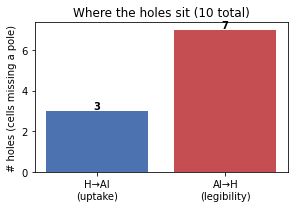

In [5]:
import matplotlib.pyplot as plt
hd = p["holes_by_direction"]
fig, ax = plt.subplots(figsize=(4.2, 3))
ax.bar(["H→AI\n(uptake)", "AI→H\n(legibility)"], [hd.get("H2AI", 0), hd.get("AI2H", 0)],
       color=["#4c72b0", "#c44e52"])
ax.set_ylabel("# holes (cells missing a pole)"); ax.set_title("Where the holes sit (10 total)")
for i, v in enumerate([hd.get("H2AI", 0), hd.get("AI2H", 0)]):
    ax.text(i, v + 0.08, str(v), ha="center", fontweight="bold")
plt.tight_layout(); plt.show()

### What we conclude — completeness skew = the legibility gap, quantified

Only **6 of 16** cells show both faces. Of the **10 holes, 7 fall in the AI→H column**. The asymmetry is the whole point: **H→AI** poles fill because what the *user* contributes is in the text, so we can see both the success and failure face; the **AI→H action-feedback** poles do *not* fill, because chat data has no actions to give feedback about. The completeness grid turns the legibility gap from a claim into a count.

## 2.2 · Polarity pairs within the complete cells
The two faces of each polarity-complete cell — the `failure` pole vs the `positive` pole. A "polarity pair" is **not** a tuple anyone picked: it is the whole cell viewed as {its failures} vs {its positives}, falling straight out of the group-by.

In [6]:
# the two poles of every complete cell, read straight off pair_analysis grid
poles = [{"cell": f"{g['op']} · {g['l1']}",
          "failure pole": ", ".join(g["failure"]),
          "positive pole": ", ".join(g["positive"])}
         for g in p["grid"] if g["status"] == "complete"]
pd.DataFrame(poles)

,cell,failure pole,positive pole
0,ask_clarify · H2AI,generate_without_clarifying,ai_asked_clarifying_question
1,act_execute · H2AI,"intent_missed, under_delivered, over_delivered...","intent_addressed, scope_matched"
2,report_state · H2AI,silent_assumption,ai_stated_interpretation
3,report_state · AI2H,"false_confidence, performative_hedge, problem_...","problem_surfaced, appropriate_confidence, appr..."
4,recover_repair · H2AI,"repetition, error_commitment","adaptation, ai_acknowledges_correction"
5,maintain_state · H2AI,plow_through,"ai_references_prior_turn, ai_references_user_w..."


## 2.3 · Direction contrast — which operations cross the H↔AI boundary
For each op, which directions actually appear in the wild data. An op present in only one direction is a candidate structural zero (the move only makes sense on one side) — resolved in 2.4.

In [7]:
bd = p["by_direction"]

# Table A: ops spanning BOTH directions — paired H→AI vs AI→H signals
bilateral_ops = [(op, info) for op, info in bd.items() if info["span"] == "both"]
print("Table A — Ops spanning BOTH directions (4 bilateral pairs)\n")
print(f"{'control_op':<18} {'H→AI signals':^40} {'AI→H signals':^40}")
print("-" * 100)
for op, info in bilateral_ops:
    h = ", ".join(info["h2ai_signals"]) or "—"
    a = ", ".join(info["ai2h_signals"]) or "—"
    # wrap for readability
    print(f"{op:<18} H→AI: {h}")
    print(f"{'':18} AI→H: {a}")
    print()

# Table B: structurally unidirectional ops
UNIDIRECTIONAL_WHY = {
    "act_execute":       ("H→AI only", "execution is inherently uptake; AI→H = report_state (structural_zero)"),
    "confirm_authorize": ("H→AI only", "authority flows only human→agent"),
    "stop_defer":        ("AI→H only", "halt is an AI act; human-initiated stop = trigger"),
    "seek_inspect":      ("neither",   "no chat signals; agentic benchmark gap"),
}
print("Table B — Structurally unidirectional ops (4)\n")
print(f"{'control_op':<18} {'direction':<12} why")
print("-" * 90)
for op, (direction, why) in UNIDIRECTIONAL_WHY.items():
    print(f"{op:<18} {direction:<12} {why}")

print()
bilateral_signal_overlap = [
    sig for op, info in bd.items()
    for sig in info["h2ai_signals"] if sig in info["ai2h_signals"]
]
print(f"Signals appearing in BOTH directions within the same op: {bilateral_signal_overlap or '[] (none — taxonomy is non-redundant)'}")


Table A — Ops spanning BOTH directions (4 bilateral pairs)

control_op                       H→AI signals                             AI→H signals              
----------------------------------------------------------------------------------------------------
ask_clarify        H→AI: generate_without_clarifying, ai_asked_clarifying_question
                   AI→H: ai_offered_options, user_asks_clarification

report_state       H→AI: silent_assumption, ai_stated_interpretation
                   AI→H: false_confidence, performative_hedge, problem_ignored, ai_implicit_refusal, problem_surfaced, appropriate_confidence, appropriate_hedge, ai_hedges_uncertainty, ai_asserts_knowledge_limit, ai_provides_caveats, ai_warns_user, ai_flags_complexity, ai_cites_source

recover_repair     H→AI: repetition, error_commitment, adaptation, ai_acknowledges_correction, user_corrects_ai, user_implicit_correction, user_repeats_request, user_expresses_dissatisfaction, user_expresses_frustration
         

### What we conclude — direction contrast

- **4 of 8 ops are bilateral** (`report_state`, `recover_repair`, `ask_clarify`, `maintain_state`) — the same control function can fail on *either* side of the human-agent boundary. E.g. `report_state` has both `silent_assumption` (H→AI: agent failed to expose its assumption during uptake) and `false_confidence` (AI→H: agent misrepresented its certainty in output). Same function, opposite direction of breakdown.
- **4 ops are structurally unidirectional** (`act_execute`, `confirm_authorize` H→AI only; `stop_defer` AI→H only; `seek_inspect` neither) — their directionality follows from the STAMP control-loop definition, not from data sparsity. A fuller corpus would not change these.
- **Zero signals are bilateral** (no signal appears on both H→AI and AI→H sides within the same op) — each signal is an unambiguous indicator of one `(op, direction)` cell. The taxonomy partitions cleanly.


## 2.4 · Why each hole exists — the interpretive verdicts
The grid is *data*; a missing pole is an *observation*. The verdict turns on the **cause** of the missing pole — **one-sidedness alone is not a gap** (a positive-only cell can be either substrate-blocked or merely uncoded). The three causes (encoded in `pair_analysis.HOLE_VERDICTS` with a `basis` string each, so the judgment is reviewable):
1. **Structural** — the missing pole cannot exist *by the cell's definition*; it collapses into another op → **structural_zero** (not a gap).
2. **Substrate** — the missing pole **cannot be instantiated in non-agentic chat at all**: producing it *requires* a tool call, a consequential/irreversible action, or a tool-error/environment state chat lacks → **benchmark_gap** (genuinely undevelopable without agentic action).
3. **Curation / thinness** — the missing pole **could** be coded from chat (no substrate barrier) but the predecessor coded only one polarity, or the op is communicative and merely thin → **set_aside**.

So a one-sided cell earns **benchmark_gap** only if its *missing* pole is substrate-blocked, not merely uncoded. *(These verdicts are preliminary — they lean on cell definitions not yet locked in the criteria-design round.)*

**benchmark_gap (4)** — what the agentic benchmark must add:

In [8]:
pd.DataFrame(p["verdicts"]["benchmark_gap"])  # the benchmark frontier (action-native ops)

,op,l1,status,verdict,basis
0,seek_inspect,H2AI,EMPTY,benchmark_gap,action-native (read-before-act); needs tools a...
1,confirm_authorize,H2AI,human-only,benchmark_gap,only a human acceptance signal coded; conseque...
2,stop_defer,AI2H,positive-only,benchmark_gap,substrate-blocked FAILURE = failing to HALT a ...
3,recover_repair,AI2H,positive-only,benchmark_gap,distinct failure = OPAQUE recovery (silent re-...


**structural_zero (4)** — *not* benchmark targets (the missing pole cannot exist by definition; the cell collapses into another op):

In [9]:
pd.DataFrame(p["verdicts"]["structural_zero"])

,op,l1,status,verdict,basis
0,seek_inspect,AI2H,EMPTY,structural_zero,reporting what was inspected = report_state; n...
1,confirm_authorize,AI2H,EMPTY,structural_zero,authority flows only human->agent; the AI-asks...
2,act_execute,AI2H,EMPTY,structural_zero,execute realizes user intent = inherently H->A...
3,stop_defer,H2AI,EMPTY,structural_zero,stop/defer is an AI act (AI->H); a human-initi...


**set_aside (2)** — real but thin in chat; communicative ops overlapping `report_state`, not benchmark targets:

In [10]:
pd.DataFrame(p["verdicts"]["set_aside"])

,op,l1,status,verdict,basis
0,ask_clarify,AI2H,positive-only,set_aside,present; failure pole (illegible/misleading cl...
1,maintain_state,AI2H,failure-only,set_aside,positive pole (legibly carried-forward state) ...


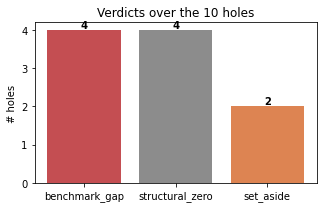

In [11]:
vc = {k: len(p["verdicts"][k]) for k in ("benchmark_gap", "structural_zero", "set_aside")}
fig, ax = plt.subplots(figsize=(4.6, 3))
ax.bar(list(vc), list(vc.values()), color=["#c44e52", "#8c8c8c", "#dd8452"])
ax.set_ylabel("# holes"); ax.set_title("Verdicts over the 10 holes")
for i, v in enumerate(vc.values()):
    ax.text(i, v + 0.06, str(v), ha="center", fontweight="bold")
plt.tight_layout(); plt.show()

## 2.5 · Headline — two independent derivations of the same frontier

The `benchmark_gap` set is **exactly the action-native operations**: `seek_inspect` / `confirm_authorize` / `stop_defer`, plus the *adequacy* branch of `recover_repair`. This is the **same cluster** the `needs_ground_truth` analysis flagged — but reached from a *totally different direction*: here via polarity-completeness, there via oracle-dependence. **Convergence from two independent methods is a real result**, not a restatement.

The experimental logic follows directly and is **falsifiable**:
- WildChat is non-agentic → the holes are *expected* → the holes are *predictions*.
- Re-running this exact contrast on the agentic Stage-A data (ShareChat/Claude) should **light up the `benchmark_gap` cells** and **leave the `structural_zero` cells empty**.

That is a sharper claim than asserting the gaps — and it ties straight into Section 3, where the agentic tool calls already show `seek_inspect` (0 chat signals) as the dominant read-before-act operation.

## 2.6 · Curated layers — masking co-occurrences & position contrasts

The two layers the columns cannot carry (hand-listed in `pair_analysis.py`, surfaced by `compute()`).

**Masking co-occurrence** — an H→AI failure whose effect is *hidden* by an AI→H failure in the same turn-pair. These are conversation-level compounds (the common-ground ablation signature), and they are the benchmark's prime targets — the canonical one being `silent_assumption × false_confidence` (agent misreads intent, then reports it confidently).

In [12]:
pd.DataFrame(p["masking"]).rename(
    columns={"h2ai": "H→AI failure", "ai2h": "masked by AI→H failure", "mechanism": "mechanism"})

,H→AI failure,masked by AI→H failure,mechanism
0,silent_assumption (H2AI report_state),false_confidence (AI2H report_state),"agent misread intent, then reports it confiden..."
1,intent_missed (H2AI act_execute),ai_implicit_refusal (AI2H report_state),agent skipped part of the task and never surfa...
2,plow_through (H2AI maintain_state),ai_self_contradiction (AI2H maintain_state),agent dropped prior context; the drift shows o...


**Position contrast** — the same control move performed on each side of the boundary (`ai_X` ↔ `user_X`): the operation is the same; only *who performs it* differs.

In [13]:
pd.DataFrame(p["position"]).rename(
    columns={"op": "operation", "ai": "AI performs", "human": "human performs"})

,operation,AI performs,human performs
0,ask_clarify,ai_asked_clarifying_question,user_asks_clarification
1,recover_repair,ai_acknowledges_correction,user_corrects_ai
